# Day 08. Exercise 04
# Regression

## 0. Imports

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

## 1. Preprocessing

In [18]:
df = pd.read_csv('../data/checker_regression.csv')
df = df.fillna(0).drop_duplicates()

del df['uid']

x = df.drop(columns=df[['AVG(diff)']])
y = df['AVG(diff)']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    random_state=21,
    test_size=0.2
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


## 2. Crossvalidation

In [19]:
def crossval(n_splits, x, y, model):
    kf = KFold(n_splits, random_state=21, shuffle=True)
    rmse = []

    for train_index, test_index in kf.split(x):

        x_train, x_test = x.iloc[train_index], x.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(x_train, y_train)

        y_test_predict = model.predict(x_test)
        y_train_predict = model.predict(x_train)

        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_predict))
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_predict))

        rmse.append(test_rmse)

        print(f'train_rmse -  {train_rmse}   |   test_rmse -  {test_rmse}')

    print(f'Average RMSE on crossval is {np.mean(rmse)}')

Linear Regression

In [20]:
linreg = LinearRegression(fit_intercept=True)
crossval(10,x,y,linreg)

train_rmse -  61.35327112662008   |   test_rmse -  57.85614740884658
train_rmse -  62.5462335194863   |   test_rmse -  44.71218893425673
train_rmse -  61.14556371253599   |   test_rmse -  83.19897138394585
train_rmse -  58.416728626194235   |   test_rmse -  79.399015977114
train_rmse -  60.11026827841826   |   test_rmse -  68.756146189296
train_rmse -  60.619323028395335   |   test_rmse -  65.92296908962915
train_rmse -  61.72075104991357   |   test_rmse -  61.800360553015715
train_rmse -  62.60680682836641   |   test_rmse -  46.68994292992783
train_rmse -  55.58034321272078   |   test_rmse -  99.08124434288634
train_rmse -  61.577932451061805   |   test_rmse -  53.24118830442656
Average RMSE on crossval is 66.06581751133447


Decision Tree Regressor

In [21]:
tree = DecisionTreeRegressor(random_state=21, max_depth = 1, min_samples_leaf=10)
crossval(10,x,y,tree)

train_rmse -  50.03169785176749   |   test_rmse -  44.66616643875419
train_rmse -  50.461795540401894   |   test_rmse -  40.05111405235178
train_rmse -  65.19958443807319   |   test_rmse -  66.72388137566139
train_rmse -  46.62409160654697   |   test_rmse -  69.51531831107476
train_rmse -  48.11196303602137   |   test_rmse -  60.173371833210226
train_rmse -  49.7527364640082   |   test_rmse -  47.15711390582638
train_rmse -  63.62087172650925   |   test_rmse -  83.05595238095238
train_rmse -  48.53500626695471   |   test_rmse -  60.351762286706354
train_rmse -  44.19970820184456   |   test_rmse -  83.80470412413216
train_rmse -  51.26526079535142   |   test_rmse -  5.4675991992336295
Average RMSE on crossval is 56.09669839079032


Random Forest Regressor

In [22]:
forest = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=21, max_samples=10)
crossval(10,x,y,forest)

train_rmse -  43.83047032231669   |   test_rmse -  56.77623751417096
train_rmse -  43.889487428077544   |   test_rmse -  55.90818088800388
train_rmse -  47.72674581660219   |   test_rmse -  32.43092943121612
train_rmse -  42.2989774951272   |   test_rmse -  58.60022309143619
train_rmse -  43.28783666370748   |   test_rmse -  57.10557064160531
train_rmse -  43.321617158800734   |   test_rmse -  64.02943081843085
train_rmse -  45.74911202532474   |   test_rmse -  26.710211526167924
train_rmse -  42.09503332558236   |   test_rmse -  51.335810810097094
train_rmse -  38.95061260148862   |   test_rmse -  87.902257780102
train_rmse -  47.851260721753704   |   test_rmse -  41.24615366309929
Average RMSE on crossval is 53.20450061643296


## 3. Predictions and evaluation

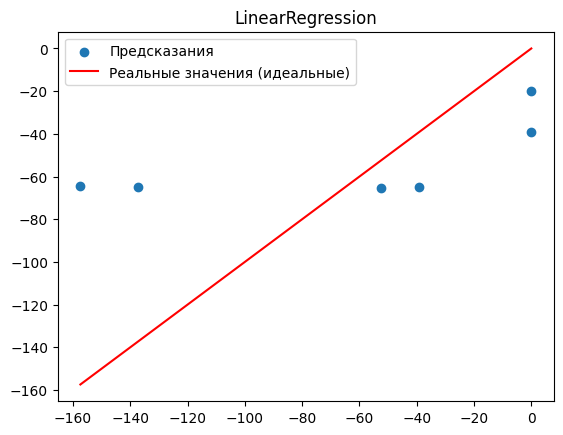

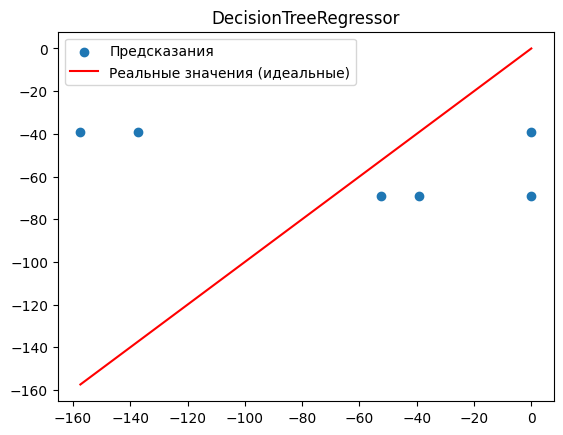

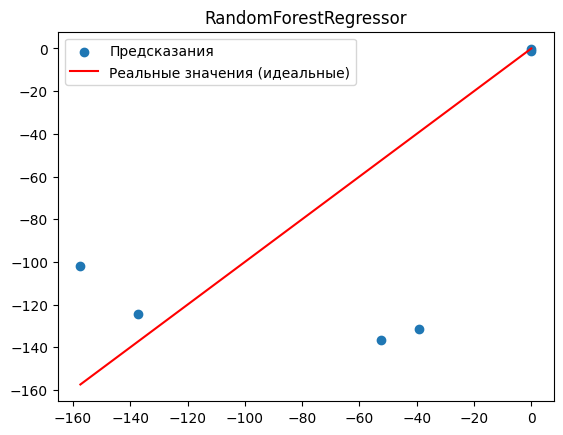

In [23]:
models = [linreg, tree, forest]
for i in models:
    i.fit(x_train, y_train)
    y_predict = i.predict(x_test)
    plt.scatter(y_test, y_predict, label='Предсказания')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Реальные значения (идеальные)')
    plt.title(i.__class__.__name__)
    plt.legend()
    plt.show()

> ***Как бы выглядел график в идеальном случае?***
>
> Ответ: ***Линия, идущая по диагонали (на графиках красная)***